<a href="https://colab.research.google.com/github/howsam/Building-a-ChatGPT-like-Model-from-Scratch/blob/main/Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <font color='#FFE15D'><b>💎 Evaluation </b></font><font color='#FF0B55'></font>

# 🔴 **Environment Setup**

## 🟠 Change the font size of the output cells

In [16]:
print('Salam Howsam!')

Salam Howsam!


In [17]:
from IPython.display import HTML
shell = get_ipython()

def adjust_font_size():
  display(HTML('''<style>
    body {
      font-size: 20px;
    }
  '''))

if adjust_font_size not in shell.events.callbacks['pre_execute']:
  shell.events.register('pre_execute', adjust_font_size)

In [18]:
print('Salam Howsam!')

Salam Howsam!


## 🟠 `pip`

In [19]:
!pip install openai

# 🔴 **Import**

In [1]:
import os
import io
import re
import math
import time
import yaml
import json
import random
import pathlib
import requests
from pprint import pprint
from tqdm.auto import tqdm
from collections import Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from tokenizers import Tokenizer

from openai import OpenAI

# 🔴 **Functions**

## 🟠 Model

In [2]:
class MultiHeadAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_embd = config.n_embd
        self.n_head = config.n_head
        self.head_size = self.n_embd // self.n_head

        self.qkv_proj = nn.Linear(self.n_embd, 3*self.n_embd, bias=False)
        self.c_proj = nn.Linear(self.n_embd, self.n_embd, bias=False)
        self.c_proj.residual = True

    def forward(self, x):
        B, T, C = x.shape
        # QKV linear
        q, k, v = self.qkv_proj(x).view(B, T, 3*self.n_head, self.head_size).transpose(1, 2).chunk(3, dim=-3)
        # Scaled Dot Product Attention using pytorch
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        # Reshape and final projection
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.c_proj(y)
        return y

In [3]:
class FeedForward(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_embd = config.n_embd
        self.f_expnd = config.f_expnd

        self.up_proj = nn.Linear(self.n_embd, int(self.f_expnd*self.n_embd), bias=False)
        self.down_proj = nn.Linear(int(self.f_expnd*self.n_embd), self.n_embd, bias=False)
        self.down_proj.residual = True

    def forward(self, x):
        return self.down_proj(F.gelu(self.up_proj(x)))

In [4]:
class DecoderBlock(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_embd = config.n_embd
        # Multi Head Attention
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.mha = MultiHeadAttention(config)
        # Feed Forward Neural Network
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.mlp = FeedForward(config)

    def forward(self, x):
        x = x + self.mha(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

In [5]:
class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.wte = nn.Embedding(config.vocab_size, config.n_embd) # Token embedding
        self.wpe = nn.Embedding(config.max_seq_len, config.n_embd) # Position embedding
        self.decoders = nn.ModuleList([DecoderBlock(config) for _ in range(config.n_layer)]) # Decoders
        self.lnf = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False) # Classifier
        self.lm_head.weight = self.wte.weight # Weight tying

        self.apply(self._init_weights)

    def _init_weights(self, module):
        std = 0.02
        if isinstance(module, nn.Linear):
            if hasattr(module, 'residual'):
                std *= (2*self.config.n_layer)**-0.5
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=std)

    def forward(self, idx):
        B, T = idx.shape
        # Token Embedding + Position Embedding
        x = self.wte(idx) + self.wpe(torch.arange(T, device=idx.device))
        # Decoders
        for decoder in self.decoders:
            x = decoder(x)
        # Classifier
        x = self.lnf(x)
        logits = self.lm_head(x)
        return logits

In [6]:
@dataclass
class GPTConfig:
    vocab_size: int = 50257
    max_seq_len: int = 1024
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    f_expnd: int = 4

## 🟠 Generate

In [7]:
def generate(model, tokenizer, prompt, n_rep=5, max_seq_len=128, T=0.9, top_k=10, device='cuda', seed=42):
    # Get the token ID for <|endoftext|>
    eot_token_id = tokenizer.encode("<|endoftext|>").ids[0]

    # Tokenize the prompt and convert it to a tensor on the specified device (e.g., GPU)
    inputs = torch.tensor(tokenizer.encode(prompt).ids, dtype=torch.int, device=device)  # Shape: [T]
    n = inputs.shape[0]

    # Repeat the input prompt n_rep times to generate multiple sequences in parallel
    inputs = inputs.unsqueeze(0).repeat(n_rep, 1)  # Shape: [B, T] where B = n_rep

    # Set the model to evaluation mode
    model.eval()

    # Initialize a random number generator for sampling
    sample_rng = torch.Generator(device=device)
    sample_rng.manual_seed(seed)

    # Track which sequences are still active
    is_finished = torch.zeros(n_rep, dtype=torch.bool, device=device)

    # Disable gradient calculation for faster inference
    with torch.no_grad():
        # Continue generating tokens until reaching the maximum sequence length
        while inputs.shape[-1] < (max_seq_len + n):
            # Forward pass: get logits from the model
            logits = model(inputs)  # Shape: [B, T, vocab_size]

            # Apply temperature scaling and softmax to get probabilities for the next token
            probs = torch.softmax(logits[:, -1, :] / T, dim=-1)  # Shape: [B, vocab_size]

            # Select the top_k tokens with the highest probabilities
            topk_probs, topk_indices = torch.topk(probs, k=top_k, dim=-1)  # Shape: [B, top_k]

            # Sample one token from the top_k candidates based on their probabilities
            sampled = torch.multinomial(topk_probs, 1, generator=sample_rng)  # Shape: [B, 1]

            # Map the sampled indices back to the original token IDs
            next_token = torch.gather(topk_indices, -1, sampled).squeeze(-1) # Shape: [B]

            # For finished sequences, force pad with eot_token_id again to avoid changing inputs
            next_token = torch.where(is_finished, torch.tensor(eot_token_id, device=device), next_token)

            # Update finished mask
            is_finished = is_finished | (next_token == eot_token_id)

            # Append the sampled tokens to the input sequence
            inputs = torch.cat((inputs, next_token.unsqueeze(-1)), dim=-1)  # Shape: [B, T+1]

    # Decode the generated sequences back into text
    generated_text = tokenizer.decode_batch(inputs.tolist())

    # Slice off the prompt part, keep only the generated continuation
    only_generated = [gen[len(prompt):] for gen in generated_text]

    return only_generated

# 🔴 **GPT-Eval**

## 🟠 Config

In [ ]:
@dataclass
class GeneralConfig:
    tokenizer_path: str
    model_path: str
    llm_eval_name: str
    api_key: str
    prompts_yaml_url: str
    n_samples: int = 10
    max_new_tokens: int = 128
    temperature: float = 1.0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

## 🟠 LLM Evaluator

In [ ]:
def deepseekv3_grade(prompt: str, completion: str):
    """
    Ask DeepSeek-V3 (model 'deepseek-chat') to grade a TinyStories completion.
    Returns a list in the order [grammar, creativity, consistency, plot].
    """
    delim = "***"
    full_text = f"{prompt.strip()} {delim} {completion.strip()}"

    system_msg = (
        "You are an English teacher grading a student's story completion. "
        "Return ONLY a JSON object with keys grammar, creativity, consistency, plot "
        "— each an integer 0-10."
    )

    user_msg = (
        "Here is the story. The part after the three asterisks (***) is the student's "
        "completion. Evaluate and respond ONLY with the JSON described.\n\n"
        f"{full_text}"
    )

    response = client.chat.completions.create(
        model = "deepseek-chat",
        messages = [
            {"role": "system", "content": system_msg},
            {"role": "user",   "content": user_msg}
        ],
        temperature = 0  # deterministic grading
    )

    # Extract JSON part (remove ```json ... ```)
    json_str = re.search(r"\{.*?\}", response.choices[0].message.content, re.DOTALL).group(0)

    # Parse and reorder the values
    grades_dict = json.loads(json_str)
    return [grades_dict[k] for k in ["grammar", "creativity", "consistency", "plot"]]

## 🟠 Evaluation

In [ ]:
# 0: General config

gen_cfg = GeneralConfig(
    tokenizer_path = 'data/bpe-tokenizer_tinystories.json',
    model_path = 'weights/model_hdim-512_layer-8_lossv129.pt',
    llm_eval_name = 'deepseek-chat',
    api_key = open("others/deepseek_api_key.txt", "r").read().strip(),
    max_new_tokens = 256,
    prompts_yaml_url = (
        "https://huggingface.co/datasets/roneneldan/TinyStories/"
        "resolve/main/Evaluation%20prompts.yaml"
    )
)

In [ ]:
# 1: Load prompts
data = requests.get(gen_cfg.prompts_yaml_url, timeout=30).text
prompts = yaml.safe_load(io.StringIO(data))
type(prompts), len(prompts)

In [ ]:
prompts[-1]

In [ ]:
# 2: Load tokenizer
tokenizer = Tokenizer.from_file(gen_cfg.tokenizer_path)

In [ ]:
# 3: Load Pretrained GPT model

gpt_cfg = GPTConfig(
    vocab_size=10_000,
    max_seq_len=1024,
    n_layer=8,
    n_head=16,
    n_embd=512,
    f_expnd=4
)

model = GPT(gpt_cfg)
model.load_state_dict(torch.load(gen_cfg.model_path))
model.to(gen_cfg.device).eval()

In [ ]:
# 4: Call DeepSeek API

client = OpenAI(api_key=gen_cfg.api_key, base_url="https://api.deepseek.com")

In [ ]:
# 5: Evaluate the quality of student GPT completions using the LLM teacher as a reference

results = []

for prompt_id, prompt in enumerate(tqdm(prompts, desc="Prompts")):
    # Generate
    completions = generate(
        model, tokenizer, prompt,
        n_rep=gen_cfg.n_samples, max_seq_len=256,
        T=gen_cfg.temperature, top_k=10
    )

    prompt_scores = []
    for i, completion in enumerate(completions):
        # Grade
        grades = deepseekv3_grade(prompt, completion)  # [grammar, ...]
        prompt_scores.append(grades)
        time.sleep(1.2)  # polite rate-limit; tweak as needed
    prompt_scores = np.array(prompt_scores)
    mean_scores   = prompt_scores.mean(axis=0)

    results.append({
        "prompt_id": prompt_id,
        "prompt": prompt,
        "completions": completions,
        "grammar": mean_scores[0],
        "creativity":mean_scores[1],
        "consistency":mean_scores[2],
        "plot": mean_scores[3]
    })

In [ ]:
df = pd.DataFrame(results)
overall = df.mean(numeric_only=True)

display(df.head())
display(overall)

In [ ]:
prompt_scores

In [ ]:
pprint(prompt)
print()
pprint(completions[1])
print()
print(tokenizer.encode(completions[1]))

In [ ]:
torch.cuda.empty_cache()

# 🔴 **ROUGE**

## 🟠 Config

In [8]:
@dataclass
class GeneralConfig:
    tokenizer_path: str
    model_path: str
    n_examples: int = 100
    split_ratio: float = 0.4  # keep first 40 % as prompt
    max_new_tokens: int = 256
    n_samples: int = 10
    temperature: float = 1.0
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    random_seed: int = 42
    k_values = [2, 4, 5]  # n-gram sizes to analyse

## 🟠 ROUGE

In [9]:
def rouge_k_precision(t1, t2, k=2):
    # Build k-gram sets
    grams1 = set(zip(*[t1.split()[i:] for i in range(k)]))
    grams2 = set(zip(*[t2.split()[i:] for i in range(k)]))
    if not grams1: return 0.0
    overlap = grams1 & grams2
    return len(overlap) / len(grams1)

In [21]:
t1 = "the cat sat on the mat"
t2 = "the cat lay on the mat"
# rouge_k_precision(t1, t2, k=2)

k = 2
grams1 = set(zip(*[t1.split()[i:] for i in range(k)]))
grams2 = set(zip(*[t2.split()[i:] for i in range(k)]))
print(grams1)
print(grams2)

overlap = grams1 & grams2

len(overlap) / len(grams1)

{('the', 'mat'), ('sat', 'on'), ('cat', 'sat'), ('on', 'the'), ('the', 'cat')}
{('the', 'mat'), ('the', 'cat'), ('cat', 'lay'), ('on', 'the'), ('lay', 'on')}


0.6

In [22]:
def rouge_k_fmeasure(t1, t2, k=2):
    p = rouge_k_precision(t1, t2, k)
    r = rouge_k_precision(t2, t1, k)
    if p + r == 0: return 0.0
    return 2 * p * r / (p + r)

In [23]:
def corpus_kgram_freq(dataset_texts, k):
    counter = Counter()
    for txt in tqdm(dataset_texts, desc=f"Counting {k}-grams"):
        counter.update(zip(*[txt.split()[i:] for i in range(k)]))
    return counter

In [24]:
def closest_story_score(gen, corpus_texts):
    return max(rouge_k_precision(gen, story, k=2) for story in corpus_texts)

## 🟠 Evaluation

In [25]:
# 0: General config

gen_cfg = GeneralConfig(
    tokenizer_path = 'data/bpe-tokenizer_tinystories.json',
    model_path = 'weights/model_hdim-512_layer-8_lossv129.pt',
    n_samples = 1
)

random.seed(gen_cfg.random_seed)

In [26]:
# 1: Load TinyStories
dataset = load_dataset("roneneldan/TinyStories", split="train")

Using the latest cached version of the dataset since roneneldan/TinyStories couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Howsam\.cache\huggingface\datasets\roneneldan___tiny_stories\default\0.0.0\f54c09fd23315a6f9c86f9dc80f725de7d8f9c64 (last modified on Sat Apr 12 16:34:29 2025).


In [27]:
# 2: Select 100 random stories
def split_story(text, ratio=0.4):
    words = text.strip().split()
    cut = max(1, int(len(words) * ratio))
    return " ".join(words[:cut]), " ".join(words[cut:])

indices = random.sample(range(len(dataset)), gen_cfg.n_examples)
examples = [dataset[i]["text"] for i in indices]
prompts, originals = zip(*(split_story(t) for t in examples))

In [29]:
prompts[0], originals[0]

('One day, a little boy named Tim was very excited. He saw a big gray dog in the park. The dog was playing with a ball. Tim wanted to play with the dog too. Tim went to his',
 'mom and asked her to explain why the dog was gray. His mom said, "The dog is gray because it has gray fur. Just like how you have brown hair, the dog has gray fur." Tim was happy to learn about the gray dog. He went to play with the dog and they had lots of fun together.')

In [30]:
# 3: Load tokenizer
tokenizer = Tokenizer.from_file(gen_cfg.tokenizer_path)

In [31]:
# 4: Load Pretrained GPT model

gpt_cfg = GPTConfig(
    vocab_size=10_000,
    max_seq_len=1024,
    n_layer=8,
    n_head=16,
    n_embd=512,
    f_expnd=4
)

model = GPT(gpt_cfg)
model.load_state_dict(torch.load(gen_cfg.model_path))
model.to(gen_cfg.device).eval()

GPT(
  (wte): Embedding(10000, 512)
  (wpe): Embedding(1024, 512)
  (decoders): ModuleList(
    (0-7): 8 x DecoderBlock(
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (mha): MultiHeadAttention(
        (qkv_proj): Linear(in_features=512, out_features=1536, bias=False)
        (c_proj): Linear(in_features=512, out_features=512, bias=False)
      )
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (mlp): FeedForward(
        (up_proj): Linear(in_features=512, out_features=2048, bias=False)
        (down_proj): Linear(in_features=2048, out_features=512, bias=False)
      )
    )
  )
  (lnf): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=512, out_features=10000, bias=False)
)

In [32]:
# 5: Generate
completions = []
for prompt in tqdm(prompts, desc="Generating"):
    completions.append(
        generate(
            model, tokenizer, prompt,
            n_rep=gen_cfg.n_samples, max_seq_len=256,
            T=gen_cfg.temperature, top_k=10
        )[0]
    )

Generating:   0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\Howsam\AppData\Local\Temp\ipykernel_16352\2308121339.py:18: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  y = F.scaled_dot_product_attention(q, k, v, is_causal=True)


In [33]:
pprint(completions[0])
print()
pprint(originals[0])

(' mom and said, "Mom, can I play with the gray dog?"\n'
 '\n'
 'His mom said, "Yes, Tim. You can play with the dog." Tim was very happy. He '
 'went to the park with the big gray dog. He threw the ball and the dog ran to '
 'get it.\n'
 '\n'
 "As they played, the ball hit a man's car. The car was going very fast. Tim's "
 'mom was scared. She said, "Tim, we have to hurry and go home now." Tim '
 'looked at the car and saw a big, red car on the road. He said, "Mom, I '
 'don\'t like this car. It\'s too fast."\n'
 '\n'
 'Tim and his mom hurried home. Tim said, "Mom, the gray dog is here. It '
 'won\'t hit the car. I\'m glad we hurried." Tim smiled and hugged his mom. '
 'They went inside and had a fun day together.')

('mom and asked her to explain why the dog was gray. His mom said, "The dog is '
 'gray because it has gray fur. Just like how you have brown hair, the dog has '
 'gray fur." Tim was happy to learn about the gray dog. He went to play with '
 'the dog and they had lots of f

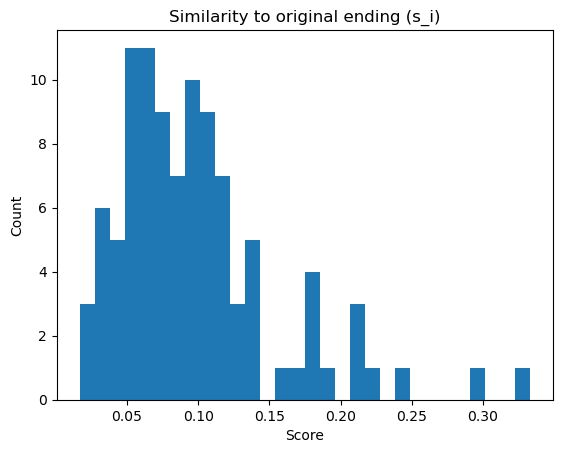

In [34]:
# 6.1: s_i
s_scores = [rouge_k_precision(gen, orig, k=2) for gen, orig in zip(completions, originals)]

plt.hist(s_scores, bins=30)
plt.title("Similarity to original ending (s_i)")
plt.xlabel("Score"); plt.ylabel("Count");

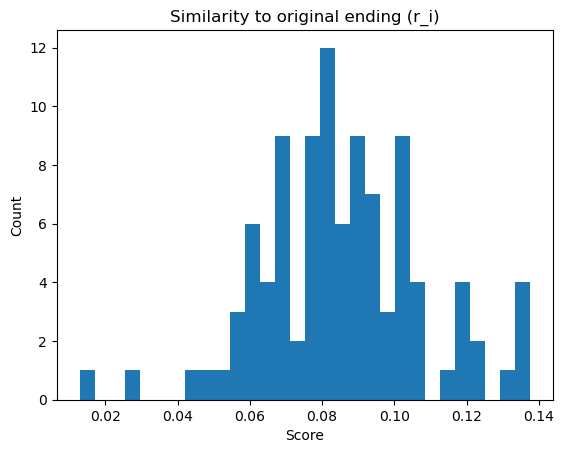

In [36]:
# 6.2: r_i
r_scores = []
for i, ti in enumerate(completions):
    others = [tj for j, tj in enumerate(completions) if j != i]
    r_scores.append(max(rouge_k_fmeasure(ti, tj, k=2) for tj in others))

plt.hist(r_scores, bins=30)
plt.title("Similarity to original ending (r_i)")
plt.xlabel("Score"); plt.ylabel("Count");

In [ ]:
# 6.3: g_r – frequency of each k-gram in training corpus
# corpus_4gram_freq = corpus_kgram_freq(dataset["text"], k=4)  # can be slow; cache result
# g_values = [math.log10(corpus_4gram_freq[gram]) if corpus_4gram_freq[gram] else -10
#             for gen in completions
#             for gram in zip(*[gen.split()[i:] for i in range(4)])]

In [ ]:
# 6.4: h_i
# h_scores = [closest_story_score(gen, dataset["text"]) for gen in tqdm(completions, desc="Closest story")]

In [ ]:
# 7: Save to disk
# out = {"s_scores": s_scores, "r_scores": r_scores, "g_values": g_values, "h_scores": h_scores}
# pathlib.Path("tiny_rouge_results.json").write_text(json.dumps(out, indent=2))
# print("Saved results to tiny_rouge_results.json")

In [ ]:
# 8: Plot histogram
# data = json.load(open("tiny_rouge_results.json"))

# for key, title in [("s_scores", "Similarity to original ending (s_i)"),
#                    ("r_scores", "Max similarity between completions (r_i)"),
#                    ("g_values", "4-gram freq in corpus (g_r)"),
#                    ("h_scores", "Closest story similarity (h_i)")]
#                    ]:
#     plt.figure()
#     plt.hist(data[key], bins=30)
#     plt.title(title)
#     plt.xlabel("Score"); plt.ylabel("Count")
    # plt.tight_layout()
    # plt.show()

# 🔴 **Perplexity**

In [38]:
valid_loss = 1.29
perplexity = math.exp(valid_loss)
print(f"Perplexity: {perplexity:.2f}")

Perplexity: 3.63
